In [1]:
import glob
import os
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate

C:\Users\khair\AppData\Local\Temp\ipykernel_20768\455826208.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


In [2]:
documents = []

files = glob.glob(r"C:\Users\khair\AI Data Analyst Project\knowledge\*.txt")

for file in files:
    loader = TextLoader(file)
    documents.extend(loader.load())
print(documents)

[Document(metadata={'source': 'C:\\Users\\khair\\AI Data Analyst Project\\knowledge\\business_metrics.txt'}, page_content="ABC RETAIL PVT. LTD.\nBUSINESS METRICS AND KPI DEFINITIONS\n\nDocument Code: BMD-001\nDepartment: Data & Analytics\nApplicable Area: Business Performance Measurement\nEffective Period: January 2025 onwards\n\n1. PURPOSE\n\nABC Retail Pvt. Ltd. uses standardized business metrics to monitor sales, customers, products, employees, and departments.\n\nThe purpose of this document is to establish consistent definitions for commonly used business performance indicators.\n\nAll departments should use the approved definitions when discussing company performance.\n\n2. TOTAL ORDERS\n\nTotal Orders represents the number of orders recorded by ABC Retail Pvt. Ltd. during a specified period.\n\nOrders are identified using unique order IDs.\n\nTotal Orders may include orders with different statuses, including Delivered, Shipped, Pending, Cancelled, and Refunded.\n\nManagement sho

In [3]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = text_splitter.split_documents(documents)

print("Total documents:", len(documents))
print("Total chunks:", len(chunks))

Total documents: 7
Total chunks: 92


In [4]:
for chunk in chunks:
    print(chunk)

page_content='ABC RETAIL PVT. LTD.
BUSINESS METRICS AND KPI DEFINITIONS

Document Code: BMD-001
Department: Data & Analytics
Applicable Area: Business Performance Measurement
Effective Period: January 2025 onwards

1. PURPOSE

ABC Retail Pvt. Ltd. uses standardized business metrics to monitor sales, customers, products, employees, and departments.

The purpose of this document is to establish consistent definitions for commonly used business performance indicators.

All departments should use the approved definitions when discussing company performance.

2. TOTAL ORDERS

Total Orders represents the number of orders recorded by ABC Retail Pvt. Ltd. during a specified period.

Orders are identified using unique order IDs.' metadata={'source': 'C:\\Users\\khair\\AI Data Analyst Project\\knowledge\\business_metrics.txt'}
page_content='Orders are identified using unique order IDs.

Total Orders may include orders with different statuses, including Delivered, Shipped, Pending, Cancelled, and

In [5]:
# !pip install langchain-chroma chromadb

In [6]:
# !pip install langchain-huggingface sentence-transformers

In [5]:
vectors = []
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

for chunk in chunks:
    vector = embeddings.embed_query(chunk.page_content)
    vectors.append(vector)
print('Number of vectors', len(vectors))
print('len of each vector', len(vectors[0]))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Number of vectors 92
len of each vector 384


In [6]:
vectorstore = Chroma(
    collection_name="company_knowledge",
    persist_directory="chroma_db"
) 

for i in range(len(chunks)):
    vectorstore._collection.add(ids = [str(i)], 
                                embeddings = [vectors[i]], 
                                documents = [chunks[i].page_content], 
                                metadatas = [chunks[i].metadata])
print("Vectors stored successfully in ChromaDB!")

Vectors stored successfully in ChromaDB!


In [7]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = Chroma(
    collection_name="company_knowledge",
    persist_directory="chroma_db",
    embedding_function=embeddings
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [8]:
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [9]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    api_key=api_key
)

In [10]:
response = llm.invoke("What is RAG?")
print(response.content)

**RAG = Retrieval‑Augmented Generation**

In the context of modern language‑model applications, **RAG** stands for **Retrieval‑Augmented Generation**. It is a hybrid architecture that combines two complementary capabilities:

| Component | What it does | Typical model |
|-----------|--------------|---------------|
| **Retriever** | Searches an external knowledge source (documents, database, vector store, API, etc.) and returns the most relevant pieces of information for a given query. | Dense vector retrievers (e.g., FAISS, Milvus, Elastic Search with embeddings), sparse lexical retrievers (BM25), hybrid retrievers, or LLM‑based “search‑engine” prompts. |
| **Generator** | Takes the retrieved passages (often concatenated with the original user prompt) and produces a natural‑language answer, summary, or any other text output. | Large language models (LLMs) such as GPT‑4, LLaMA‑2, Claude, Gemini, or open‑source models fine‑tuned for instruction following. |

The overall flow is:

1. **Us

In [11]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

In [12]:
query = "What is the refund policy?"

results = retriever.invoke(query)

for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)
    print("Metadata:", doc.metadata)


--- Result 1 ---
Sales employees should not independently approve refunds unless they have the required authority.

Sales teams should coordinate with Customer Service and Finance when necessary.

12. FINANCE RESPONSIBILITIES

The Finance Department is responsible for the financial processing associated with approved refunds.

Finance should maintain appropriate records of refund transactions according to company financial procedures.

Refund information should be reconciled with approved customer service records.

13. REFUND MONITORING

Management should monitor refund activity periodically.

Useful business measures include:

* Number of refunded orders
* Refund rate
* Refunds by month
* Refunds by product
* Refunds by category
* Refunds by customer segment
* Refunds by location
Metadata: {'source': 'C:\\Users\\khair\\AI Data Analyst Project\\knowledge\\refund_policy.txt'}

--- Result 2 ---
Refund requests should be reviewed before approval.

The company may consider:

* Order statu

In [13]:
context = "\n\n".join(
    doc.page_content
    for doc in results
)

print(context)

Sales employees should not independently approve refunds unless they have the required authority.

Sales teams should coordinate with Customer Service and Finance when necessary.

12. FINANCE RESPONSIBILITIES

The Finance Department is responsible for the financial processing associated with approved refunds.

Finance should maintain appropriate records of refund transactions according to company financial procedures.

Refund information should be reconciled with approved customer service records.

13. REFUND MONITORING

Management should monitor refund activity periodically.

Useful business measures include:

* Number of refunded orders
* Refund rate
* Refunds by month
* Refunds by product
* Refunds by category
* Refunds by customer segment
* Refunds by location

Refund requests should be reviewed before approval.

The company may consider:

* Order status
* Product involved
* Customer request
* Applicable return conditions
* Order processing stage
* Customer service information
* Bu

In [14]:
prompt = PromptTemplate(
    template="""
You are an AI Data Analyst assistant for ABC Retail Pvt. Ltd.

Answer the user's question using only the provided context.

If the answer is not available in the context, say:
"I don't have enough information in the company knowledge base."

Do not make up information.

Context:
{context}

Question:
{question}

Answer:
""",
    input_variables=["context", "question"]
)

In [15]:
final_prompt = prompt.format(
    context=context,
    question=query
)

print(final_prompt)


You are an AI Data Analyst assistant for ABC Retail Pvt. Ltd.

Answer the user's question using only the provided context.

If the answer is not available in the context, say:
"I don't have enough information in the company knowledge base."

Do not make up information.

Context:
Sales employees should not independently approve refunds unless they have the required authority.

Sales teams should coordinate with Customer Service and Finance when necessary.

12. FINANCE RESPONSIBILITIES

The Finance Department is responsible for the financial processing associated with approved refunds.

Finance should maintain appropriate records of refund transactions according to company financial procedures.

Refund information should be reconciled with approved customer service records.

13. REFUND MONITORING

Management should monitor refund activity periodically.

Useful business measures include:

* Number of refunded orders
* Refund rate
* Refunds by month
* Refunds by product
* Refunds by categ

In [16]:
response = llm.invoke(final_prompt)
print(response.content)

**Refund Policy – ABC Retail Pvt. Ltd. (Document RCP‑001)**  

1. **Purpose**  
   - Establishes procedures for handling customer order cancellations and refunds.  
   - Requires accurate recording of order status (Delivered, Shipped, Pending, Cancelled, Refunded).

2. **Refund Process**  
   1. Customer submits a refund request.  
   2. **Customer Service** reviews the request, verifies order details (ID, date, product, status, reason) and assesses eligibility.  
   3. If required, **approval** is obtained (Sales, Finance, or Management as per business approval requirements).  
   4. Once approved, the order is recorded as **Refunded**.  
   5. **Finance** completes the financial processing and maintains proper records, reconciling refunds with approved Customer Service records.

3. **Roles & Responsibilities**  
   - **Customer Service**: Receives, reviews, and communicates status of refund requests; verifies customer and order information.  
   - **Sales**: May support communication

In [19]:
# !pip install pyodbc

In [17]:
import pyodbc

In [18]:
connection = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=HP;"
    "DATABASE=AI_Data_Analyst;"
    "Trusted_Connection=yes;"
)

print("Database connected successfully!")

Database connected successfully!


In [19]:
cursor = connection.cursor()
cursor.execute("SELECT COUNT(*) FROM customer")
result = cursor.fetchone()
print(result)

(200,)


In [53]:
def execute_query(query):

    cursor = connection.cursor()
    cursor.execute(query)
    columns = [column[0] for column in cursor.description]
    rows = cursor.fetchall()
    result = [
        dict(zip(columns, row))
        for row in rows
    ]
    return result

In [54]:
query = """
SELECT 
    d.department_name,
    COUNT(e.employee_id) AS employee_count
FROM departments d
INNER JOIN employees e
    ON d.department_id = e.department_id
GROUP BY d.department_name
"""

result = execute_query(query)

print(result)

[{'department_name': 'Data & Analytics', 'employee_count': 40}, {'department_name': 'Finance', 'employee_count': 40}, {'department_name': 'Human Resources', 'employee_count': 40}, {'department_name': 'Operations', 'employee_count': 40}, {'department_name': 'Sales', 'employee_count': 40}]


In [22]:
sql_schema = """
Database: AI_Data_Analyst

Table: customer
Columns:
- customer_id
- name
- city
- state
- signup_date
- segment

Table: products
Columns:
- product_id
- product_name
- category
- price
- cost

Table: orders
Columns:
- order_id
- customer_id
- order_date
- status

Table: order_items
Columns:
- order_item_id
- order_id
- product_id
- quantity

Table: employees
Columns:
- employee_id
- employee_name
- department_id
- job_role
- city
- hire_date
- salary

Table: departments
Columns:
- department_id
- department_name
- manager_name
- location
- annual_budget

Relationships:
- customer.customer_id = orders.customer_id
- orders.order_id = order_items.order_id
- products.product_id = order_items.product_id
- departments.department_id = employees.department_id
"""

In [23]:
print(sql_schema)


Database: AI_Data_Analyst

Table: customer
Columns:
- customer_id
- name
- city
- state
- signup_date
- segment

Table: products
Columns:
- product_id
- product_name
- category
- price
- cost

Table: orders
Columns:
- order_id
- customer_id
- order_date
- status

Table: order_items
Columns:
- order_item_id
- order_id
- product_id
- quantity

Table: employees
Columns:
- employee_id
- employee_name
- department_id
- job_role
- city
- hire_date
- salary

Table: departments
Columns:
- department_id
- department_name
- manager_name
- location
- annual_budget

Relationships:
- customer.customer_id = orders.customer_id
- orders.order_id = order_items.order_id
- products.product_id = order_items.product_id
- departments.department_id = employees.department_id



In [24]:
sql_prompt = PromptTemplate(
    template="""
You are an AI Data Analyst for ABC Retail Pvt. Ltd.

Your task is to convert the user's question into a SQL Server query.

Use only the tables and columns provided in the database schema.

Database Schema:
{schema}

Business Context:
{business_context}

Rules:
1. Generate SQL Server syntax.
2. Use only the tables and columns from the schema.
3. Use JOINs when data is required from multiple tables.
4. Use the Business Context when the question depends on a company-specific definition, policy, or rule.
5. Do not make up table names or column names.
6. Return only the SQL query.
7. Do not include explanations.
8. Do not use INSERT, UPDATE, DELETE, DROP, ALTER, or TRUNCATE.

User Question:
{question}

SQL Query:
""",
    input_variables=["schema", "business_context", "question"]
)

In [25]:
# def ask_sql_question(question):

#     # Generate SQL using LLM
#     final_prompt = sql_prompt.format(
#         schema=sql_schema,
#         question=question
#     )

#     response = llm.invoke(final_prompt)
#     generated_sql = response.content

#     # Execute generated SQL
#     columns, rows = execute_query(generated_sql)
#     return generated_sql, columns, rows

In [26]:
# question = "What is the total revenue?"

# generated_sql, columns, rows = ask_sql_question(question)

# print("Generated SQL:")
# print(generated_sql)
# print("\nResult:")
# print(columns)
# print(rows)

In [27]:
def validate_sql(query):

    query = query.strip().lower()

    forbidden_keywords = [
        "insert",
        "update",
        "delete",
        "drop",
        "alter",
        "truncate"
    ]

    if not query.startswith("select"):
        return False

    for keyword in forbidden_keywords:
        if keyword in query:
            return False

    return True

In [28]:
# query = """
# SELECT COUNT(*) AS total_orders
# FROM orders;
# """
# print(validate_sql(query))

query = """
DELETE FROM orders;
"""

print(validate_sql(query))

False


In [29]:
# def ask_sql_question(question):

#     # 1. Generate SQL using LLM
#     final_prompt = sql_prompt.format(
#         schema=sql_schema,
#         question=question
#     )

#     response = llm.invoke(final_prompt)

#     generated_sql = response.content.strip()

#     # 2. Validate SQL
#     if not validate_sql(generated_sql):

#         return generated_sql, None, None

#     # 3. Execute SQL only if it is safe
#     columns, rows = execute_query(generated_sql)

#     return generated_sql, columns, rows

In [55]:
# question = "How many orders does the company have?"

# generated_sql, columns, rows = ask_sql_question(question)

# print("Generated SQL:")
# print(generated_sql)

# print("\nResult:")
# print(columns)
# print(rows)

In [31]:
answer_prompt = PromptTemplate(
    template="""
You are an AI Data Analyst for ABC Retail Pvt. Ltd.

Answer the user's question using only the SQL result provided below.

User Question:
{question}

SQL Query:
{sql}

SQL Result:
{result}

Rules:
1. Give a clear and concise answer.
2. Use only the SQL result.
3. Do not make up any information.
4. Do not explain the SQL query unless necessary.
5. If the result is a number, explain what the number represents.

Answer:
""",
    input_variables=["question", "sql", "result"]
)

In [72]:
chart_prompt = PromptTemplate(
    template="""
You are a chart recommendation assistant for ABC Retail Pvt. Ltd.

Decide whether the user's question and SQL result should be visualized as a chart.

Choose only one option:

BAR
LINE
PIE
NONE

Rules:

BAR:
Use for comparisons between categories.
Examples:
- Revenue by category
- Employees by department
- Top 5 products

LINE:
Use for values changing over time.
Examples:
- Monthly revenue
- Yearly sales
- Monthly orders

PIE:
Use for part-to-whole distributions.
Examples:
- Customer segment distribution
- Order status distribution

NONE:
Use when a chart is not useful, especially for:
- Simple single numbers
- Policies
- Definitions
- Procedures
- Questions that are mainly textual

User Question:
{question}

SQL Result:
{result}

Return only one word:
BAR
LINE
PIE
NONE
""",
    input_variables=["question", "result"]
)

In [32]:
def clean_sql(query):

    query = query.strip()
    if query.startswith("```sql"):
        query = query.replace("```sql", "", 1)
    if query.endswith("```"):
        query = query[:-3]
    return query.strip()

In [57]:
def ask_sql_question(question, business_context=""):

    # 1. Generate SQL using LLM
    final_prompt = sql_prompt.format(
        schema=sql_schema,
        business_context=business_context,
        question=question
    )

    response = llm.invoke(final_prompt)

    generated_sql = clean_sql(response.content)

    # 2. Validate SQL
    if not validate_sql(generated_sql):
        return "The generated SQL query is not safe."

    # 3. Execute SQL safely
    try:
        result = execute_query(generated_sql)

    except Exception as e:
        return f"SQL execution failed: {str(e)}"

    # 4. Generate natural-language answer
    final_answer_prompt = answer_prompt.format(
        question=question,
        sql=generated_sql,
        result=result
    )

    answer = llm.invoke(final_answer_prompt)

    return answer.content

In [61]:
# question = "What does ABC Retail define as Total Orders?"
# answer = ask_sql_question(question)
# print(answer)

# question = "How many customers do we have?"
# answer = ask_sql_question(question)
# print(answer)

# question = "What is the total revenue?"
# answer = ask_sql_question(question)
# print(answer)

# question = "What is the average salary in each department?"
# answer = ask_sql_question(question)
# print(answer)

question = "Which product category generated the highest revenue?"
answer = ask_sql_question(question)
print(answer)

The product category that generated the highest revenue is **Electronics**, with a total revenue of **2,423,500.00**.


In [35]:
router_prompt = PromptTemplate(
    template="""
You are a question router for an AI Data Analyst system.

Classify the user's question into one of these categories:

SQL
RAG
BOTH

SQL:
Use SQL when the question requires actual database data,
numbers, counts, calculations, filtering, grouping, sorting,
or aggregation, AND the question can be answered using the
database schema without needing company-specific definitions,
policies, rules, or guidelines.

RAG:
Use RAG when the question asks about company policies,
rules, definitions, guidelines, procedures, or other information
stored in the company knowledge documents, and does not require
actual database data.

BOTH:
Use BOTH when the question requires actual database data AND
company-specific knowledge, definitions, policies, rules, or
guidelines.

IMPORTANT:
If a question contains a business term whose meaning is defined
in the company knowledge base, and the question also asks for
actual database data, classify it as BOTH.

Examples:

Question: How many orders does the company have?
Category: SQL

Question: What is the refund policy?
Category: RAG

Question: What is the refund policy and how many refunded orders do we have?
Category: BOTH

Question: Which product category generated the highest revenue?
Category: SQL

Question: How does ABC Retail classify its customers?
Category: RAG

Question: How does the company define completed orders and how many completed orders are there?
Category: BOTH

Question: How many completed orders were there in 2025?
Category: BOTH

Question: What is the refund rate for Premium customers?
Category: BOTH

Question: How many employees work in the Sales department?
Category: SQL

Question: What are the rules for processing refunds?
Category: RAG

Return only one word:
SQL
RAG
BOTH

User Question:
{question}

Category:
""",
    input_variables=["question"]
)

In [36]:
def route_question(question):
    final_prompt = router_prompt.format(
        question=question
    )
    response = llm.invoke(final_prompt)
    route = response.content.strip().upper()
    return route

In [37]:
question = "How many orders does the company have?"
route = route_question(question)
print(route)

SQL


In [38]:
# question = "How many orders does the company have?"
# router_final_prompt = router_prompt.format(
#     question=question
# )
# response = llm.invoke(router_final_prompt)
# print(response.content)

# question = "What is the refund policy?"
# router_final_prompt = router_prompt.format(
#     question=question
# )
# response = llm.invoke(router_final_prompt)
# print(response.content)

# question = "What is the refund policy and how many refunded orders do we have?"
# router_final_prompt = router_prompt.format(
#     question=question
# )
# response = llm.invoke(router_final_prompt)
# print(response.content)

In [39]:
def ask_rag_question(question):

    # 1. Retrieve relevant documents
    results = retriever.invoke(question)

    # 2. Create context
    context = "\n\n".join(
        doc.page_content
        for doc in results
    )

    # 3. Create final prompt
    final_prompt = prompt.format(
        context=context,
        question=question
    )

    # 4. Generate answer
    response = llm.invoke(final_prompt)
    return response.content

In [40]:
question = "What is the refund policy?"
answer = ask_rag_question(question)
print(answer)

**Refund Policy – ABC Retail Pvt. Ltd. (Document RCP‑001)**  

1. **Purpose**  
   - Establishes procedures for handling customer order cancellations and refunds.  
   - Requires accurate recording of order status (Delivered, Shipped, Pending, Cancelled, Refunded).

2. **Refund Process**  
   1. Customer submits a refund request.  
   2. Customer Service reviews the request and verifies details (customer identity, order ID, date, product, status, reason, applicable conditions).  
   3. Order details are verified and eligibility is assessed.  
   4. Approval is obtained when required (sales may need to coordinate with Customer Service and Finance; sales staff may only approve if they have the required authority).  
   5. Once approved, the order is recorded as **Refunded**.  
   6. Finance completes the financial processing and maintains appropriate records, reconciling refund information with approved Customer Service records.

3. **Roles & Responsibilities**  
   - **Customer Service:

In [66]:
# def ask_question(question):

#     # 1. Decide where the question should go
#     route = route_question(question)

#     # 2. Send question to the correct pipeline
#     if route == "SQL":
#         return ask_sql_question(question)
#     elif route == "RAG":
#         return ask_rag_question(question)
#     else:
#         return "BOTH case will be handled next."

In [42]:
# question = "How many orders does the company have?"
# answer = ask_question(question)
# print(answer)

# question = "What is the refund policy?"
# answer = ask_question(question)
# print(answer)

In [63]:
def ask_both_question(question):

    # 1. Retrieve relevant company knowledge
    results = retriever.invoke(question)

    # 2. Create RAG context
    rag_context = "\n\n".join(
        doc.page_content
        for doc in results
    )

    # 3. Generate SQL using company knowledge
    final_prompt = sql_prompt.format(
        schema=sql_schema,
        business_context=rag_context,
        question=question
    )

    response = llm.invoke(final_prompt)

    generated_sql = clean_sql(response.content)

    # 4. Validate SQL
    if not validate_sql(generated_sql):
        return "The generated SQL query is not safe."

    # 5. Execute SQL
    try:
        sql_result = execute_query(generated_sql)
    except Exception as e:
        return f"SQL execution failed: {str(e)}"

    # 6. Generate final answer using RAG + RAW SQL result
    combined_prompt = f"""
You are an AI Data Analyst for ABC Retail Pvt. Ltd.

Answer the user's question using both the company knowledge base
and the SQL database result.

User Question:
{question}

Company Knowledge Base:
{rag_context}

SQL Database Result:
{sql_result}

Rules:
1. Use only the information provided above.
2. Do not make up information.
3. Use the company knowledge base for definitions, policies, rules,
   and business terminology.
4. Use the SQL database result for actual numbers and data.
5. Give a clear and concise answer.
6. If the SQL result contains a number, use that exact number.
7. Do not mention the SQL query unless necessary.

Final Answer:
"""

    final_response = llm.invoke(combined_prompt)

    return final_response.content

In [64]:
# question = "What is the refund policy and how many refunded orders do we have?"
# answer = ask_both_question(question)
# print(answer)

question = "How many completed orders were there in 2025?"
answer = ask_both_question(question)
print(answer)

In 2025, there were **71 completed orders** (i.e., orders with the status *Delivered*).


In [44]:
def ask_question(question):

    # 1. Decide where the question should go
    route = route_question(question)

    # 2. Send question to the correct pipeline
    if route == "SQL":
        return ask_sql_question(question)
    elif route == "RAG":
        return ask_rag_question(question)
    elif route == "BOTH":
        return ask_both_question(question)
    else:
        return "Unable to determine the question type."

In [45]:
# question = "What is the refund policy and how many refunded orders do we have?"
# answer = ask_question(question)
# print(answer)

question = "How many orders does the company have?"
answer = ask_question(question)
print(answer)

The company has **200 orders** in total. This number is the count of all records in the `orders` table.


In [46]:
# questions = [
#     "How many customers do we have?",
#     "How many orders do we have?",
#     "What is the total revenue?",
#     "Which product category generated the highest revenue?",
#     "What is the average salary in each department?"
# ]

# for question in questions:
#     print("\nQuestion:", question)
#     print("Route:", route_question(question))
#     print("Answer:", ask_question(question))

# questions = [
#     "What is the refund policy?",
#     "How does ABC Retail classify its customers?",
#     "What does ABC Retail define as Total Orders?",
#     "What are the company's guidelines?"
# ]

# for question in questions:
#     print("\nQuestion:", question)
#     print("Route:", route_question(question))
#     print("Answer:", ask_question(question))

# questions = [
#     "What is the refund policy and how many refunded orders do we have?",
#     "How does the company define completed orders and how many completed orders are there?"
# ]

# for question in questions:
#     print("\nQuestion:", question)
#     print("Route:", route_question(question))
#     print("Answer:", ask_question(question))

In [47]:
business_context = """
According to ABC Retail's company policy,
a Completed Order is an order whose status is 'Delivered'.
"""

final_prompt = sql_prompt.format(
    schema=sql_schema,
    business_context=business_context,
    question="How many completed orders are there?"
)

response = llm.invoke(final_prompt)
generated_sql = clean_sql(response.content)
print(generated_sql)

SELECT COUNT(*) AS completed_orders_count
FROM orders
WHERE status = 'Delivered';


In [48]:
# question = "How does the company define completed orders and how many completed orders are there?"
# answer = ask_question(question)
# print(answer) 

# question = "How many customers do we have?"
# answer = ask_question(question)
# print(answer)

# question = "What is the total revenue?"
# answer = ask_question(question)
# print(answer)

# question = "Which product category generated the highest revenue?"
# answer = ask_question(question)
# print(answer)

# question = "What is the refund policy?"
# answer = ask_question(question)
# print(answer)

# question = "How does ABC Retail classify its customers?"
# answer = ask_question(question)
# print(answer)

# question = "What is the refund policy and how many refunded orders do we have?"
# answer = ask_question(question)
# print(answer)

# question = "How does the company define completed orders and how many completed orders are there?"
# answer = ask_question(question)
# print(answer)

# question = "How many orders were cancelled?"
# answer = ask_question(question)
# print(answer)

# question = "What was the total revenue in 2025?"
# answer = ask_question(question)
# print(answer)

# question = "What is the average salary in each department?"
# answer = ask_question(question)
# print(answer)

# question = "What are the rules for processing refunds?"
# answer = ask_question(question)
# print(answer)

# question = "How many completed orders were there in 2025?"
# answer = ask_question(question)
# print(answer)

# question = "What are the top 5 products by revenue?"
# answer = ask_question(question)
# print(answer)

# question = "How much revenue was generated by Premium customers?"
# answer = ask_question(question)
# print(answer)

# question = "What was the monthly revenue in 2025?"
# answer = ask_question(question)
# print(answer)

# question = "How many orders does each customer segment have?"
# answer = ask_question(question)
# print(answer)

question = "What is the company's definition of completed orders and what percentage of all orders were completed?"
answer = ask_question(question)
print(answer)

**Definition of a Completed Order**  
A *Completed Order* is an order whose status is **Delivered**. Delivered indicates that the customer's order has successfully reached the customer.

**Percentage of Completed Orders**  
Based on the current data in the SQL database, **57 %** of all orders have the status *Delivered*. Therefore, 57 % of the company’s orders are considered completed.


In [130]:
# question = "What is the refund policy and how many refunded orders do we have?"
# rag_answer = ask_rag_question(question)
# print(rag_answer)

In [49]:
query = "What is the refund policy?"

results = retriever.invoke(query)

for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)
    print("Metadata:", doc.metadata)


--- Result 1 ---
Sales employees should not independently approve refunds unless they have the required authority.

Sales teams should coordinate with Customer Service and Finance when necessary.

12. FINANCE RESPONSIBILITIES

The Finance Department is responsible for the financial processing associated with approved refunds.

Finance should maintain appropriate records of refund transactions according to company financial procedures.

Refund information should be reconciled with approved customer service records.

13. REFUND MONITORING

Management should monitor refund activity periodically.

Useful business measures include:

* Number of refunded orders
* Refund rate
* Refunds by month
* Refunds by product
* Refunds by category
* Refunds by customer segment
* Refunds by location
Metadata: {'source': 'C:\\Users\\khair\\AI Data Analyst Project\\knowledge\\refund_policy.txt'}

--- Result 2 ---
Refund requests should be reviewed before approval.

The company may consider:

* Order statu

In [68]:
# question = "How many completed orders were there in 2025?"
# route = route_question(question)
# print(route)

# question = "What is the company's refund policy and what percentage of orders were refunded?"
# answer = ask_question(question)
# print(answer)

# question = "How many completed orders were there in 2025?"
# answer = ask_question(question)
# print(answer)

# question = "What is the company's definition of completed orders and what percentage of all orders were completed?"
# answer = ask_question(question)
# print(answer)

# question = "What are the top 5 products by revenue?"
# answer = ask_question(question)
# print(answer)

# question = "What is the refund policy?"
# answer = ask_question(question)
# print(answer)

# question = "What is the refund policy and how many refunded orders do we have?"
# answer = ask_question(question)
# print(answer)

**Refund Policy (as defined in the company knowledge base)**  

1. **Request Initiation** – The customer submits a refund request.  
2. **Customer‑Service Review** – Customer Service reviews the request, verifies order details and assesses eligibility.  
3. **Approval** – If required, approval is obtained (sales staff may not approve refunds without the proper authority; coordination with Finance and Management may be needed).  
4. **Record the Refund** – Once approved, the order status is changed to **Refunded**.  
5. **Financial Processing** – The Finance Department completes the financial transaction and records the refund according to financial procedures.  

*Key points*  

- Sales employees cannot independently approve refunds unless they have the required authority.  
- Refunds must be coordinated with Customer Service and Finance.  
- Refunded orders are tracked separately from completed (delivered) orders and are excluded from normal sales performance metrics.  
- Management m

In [69]:
import matplotlib.pyplot as plt
def create_chart(data, x_column, y_column, chart_type="bar"):
    x_values = [row[x_column] for row in data]
    y_values = [row[y_column] for row in data]
    if chart_type == "bar":
        plt.bar(x_values, y_values)
    elif chart_type == "line":
        plt.plot(x_values, y_values, marker="o")
    elif chart_type == "pie":
        plt.pie(
            y_values,
            labels=x_values,
            autopct="%1.1f%%"
        )
    else:
        print("Unsupported chart type")
        return
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"{y_column} by {x_column}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [70]:
query = """
SELECT 
    d.department_name,
    COUNT(e.employee_id) AS employee_count
FROM departments d
INNER JOIN employees e
    ON d.department_id = e.department_id
GROUP BY d.department_name
"""

result = execute_query(query)
print(result)

[{'department_name': 'Data & Analytics', 'employee_count': 40}, {'department_name': 'Finance', 'employee_count': 40}, {'department_name': 'Human Resources', 'employee_count': 40}, {'department_name': 'Operations', 'employee_count': 40}, {'department_name': 'Sales', 'employee_count': 40}]


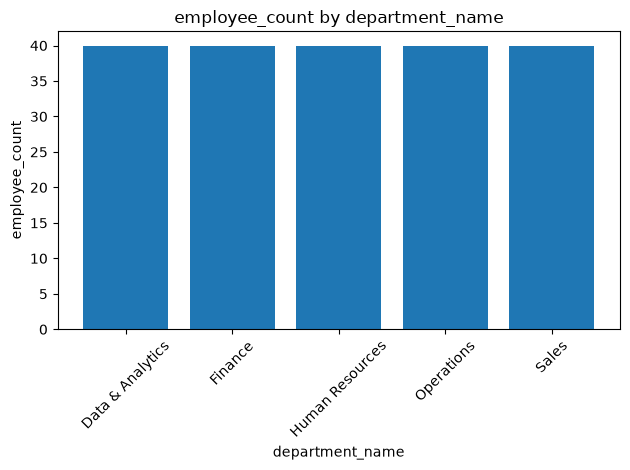

In [71]:
create_chart(
    result,
    "department_name",
    "employee_count",
    "bar"
)

In [73]:
def decide_chart(question, result):
    final_prompt = chart_prompt.format(
        question=question,
        result=result
    )
    response = llm.invoke(final_prompt)
    chart_type = response.content.strip().upper()
    return chart_type

In [81]:
def generate_chart(question, result):
    chart_type = decide_chart(question, result)
    if chart_type == "NONE":
        print("No chart required.")
        return
    # Get column names
    columns = list(result[0].keys())
    # Case 1: Two columns
    if len(columns) == 2:
        x_column = columns[0]
        y_column = columns[1]
        create_chart(
            result,
            x_column,
            y_column,
            chart_type.lower()
        )
    # Case 2: Three columns
    elif len(columns) == 3:
        # Example:
        # year | month | revenue
        if "year" in columns and "month" in columns:
            for row in result:
                row["period"] = f"{row['year']}-{row['month']:02d}"
            create_chart(
                result,
                "period",
                columns[2],
                "line"
            )
        else:
            print("Three-column result detected.")
            print("Automatic chart generation is not configured for this format yet.")
    else:
        print("This SQL result format is not supported for chart generation yet.")

[{'year': 2025, 'month': 1, 'revenue': Decimal('182800.00')}, {'year': 2025, 'month': 2, 'revenue': Decimal('223600.00')}, {'year': 2025, 'month': 3, 'revenue': Decimal('147100.00')}, {'year': 2025, 'month': 4, 'revenue': Decimal('535000.00')}, {'year': 2025, 'month': 5, 'revenue': Decimal('222300.00')}, {'year': 2025, 'month': 6, 'revenue': Decimal('174200.00')}, {'year': 2025, 'month': 7, 'revenue': Decimal('581600.00')}, {'year': 2025, 'month': 8, 'revenue': Decimal('365900.00')}, {'year': 2025, 'month': 9, 'revenue': Decimal('167400.00')}, {'year': 2025, 'month': 10, 'revenue': Decimal('254400.00')}, {'year': 2025, 'month': 11, 'revenue': Decimal('585500.00')}, {'year': 2025, 'month': 12, 'revenue': Decimal('191800.00')}]


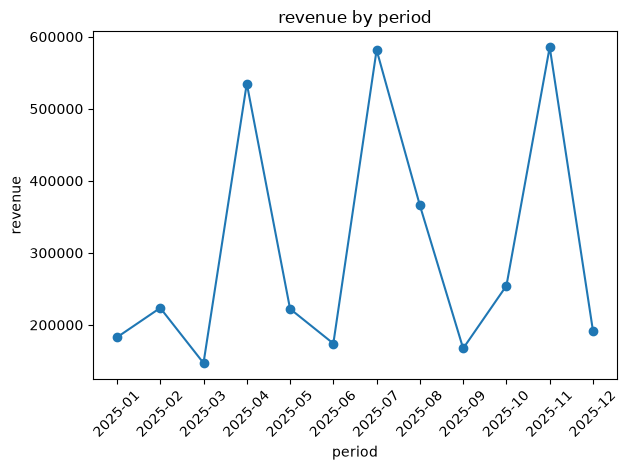

In [84]:
# query = """
# SELECT 
#     d.department_name,
#     COUNT(e.employee_id) AS employee_count
# FROM departments d
# INNER JOIN employees e
#     ON d.department_id = e.department_id
# GROUP BY d.department_name
# """
# result = execute_query(query)
# generate_chart(
#     "How many employees work in each department?",
#     result
# )

# generate_chart(
#     "How many customers do we have?",
#     [{"total_customers": 200}]
# )

# query = """
# SELECT 
#     d.department_name,
#     COUNT(e.employee_id) AS employee_count
# FROM departments d
# INNER JOIN employees e
#     ON d.department_id = e.department_id
# GROUP BY d.department_name
# """
# result = execute_query(query)
# generate_chart(
#     "How many employees work in each department?",
#     result
# )

query = """
SELECT 
    YEAR(o.order_date) AS year,
    MONTH(o.order_date) AS month,
    SUM(oi.quantity * p.price) AS revenue
FROM orders o
INNER JOIN order_items oi
    ON o.order_id = oi.order_id
INNER JOIN products p
    ON p.product_id = oi.product_id
WHERE YEAR(o.order_date) = 2025
GROUP BY 
    YEAR(o.order_date),
    MONTH(o.order_date)
ORDER BY 
    YEAR(o.order_date),
    MONTH(o.order_date)
"""
result = execute_query(query)
print(result)

generate_chart(
    "What was the monthly revenue in 2025?",
    result
)

In [74]:
chart_type = decide_chart(
    "How many employees work in each department?",
    result
)
print(chart_type)

BAR


In [75]:
chart_type = decide_chart(
    "What was the monthly revenue in 2025?",
    [
        {"month": "January", "revenue": 182800},
        {"month": "February", "revenue": 223600},
        {"month": "March", "revenue": 147100}
    ]
)
print(chart_type)

LINE


In [77]:
chart_type = decide_chart(
    "How many customers do we have?",
    [{"total_customers": 200}]
)

print(chart_type)

NONE
